## 1. Setup

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist, squareform

from sklearn.decomposition import PCA
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    pairwise_distances,
)
from sklearn.metrics.cluster import adjusted_rand_score

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook", palette="muted")
plt.rcParams["figure.dpi"] = 120

BASE_DIR  = os.path.abspath("..")
DATA_DIR  = os.path.join(BASE_DIR, "data")
PLOTS_DIR = os.path.join(BASE_DIR, "plots")
os.makedirs(PLOTS_DIR, exist_ok=True)

RANDOM_STATE = 42

## 2. Load Data

In [2]:
# Scaled feature matrix (26 cols) — output of EDA notebook
X = pd.read_csv(os.path.join(DATA_DIR, "executions_features_scaled.csv"))

# Meta — for external validation only, never touches feature matrix
meta = pd.read_csv(os.path.join(DATA_DIR, "executions_meta.csv"))

assert len(X) == len(meta), "Row mismatch between feature matrix and meta"

print(f"Feature matrix : {X.shape}")
print(f"Meta columns   : {list(meta.columns)}")
print(f"Nulls in X     : {X.isnull().sum().sum()}")

Feature matrix : (9400, 23)
Meta columns   : ['program_id', 'execution_id', 'suggestion_id', 'source_path', 'source_hash', 'pattern', 'severity', 'detector_family', 'score_dimension', 'impact_score', 'co_occurring_patterns', 'source_lines', 'score', 'efficiency_complexity_score', 'quality_score', 'maintainability_score']
Nulls in X     : 0


## 3. PCA — Dimensionality Reduction

Goal: retain 95% explained variance. Reduces noise and makes K-Medoids distance computation more meaningful.

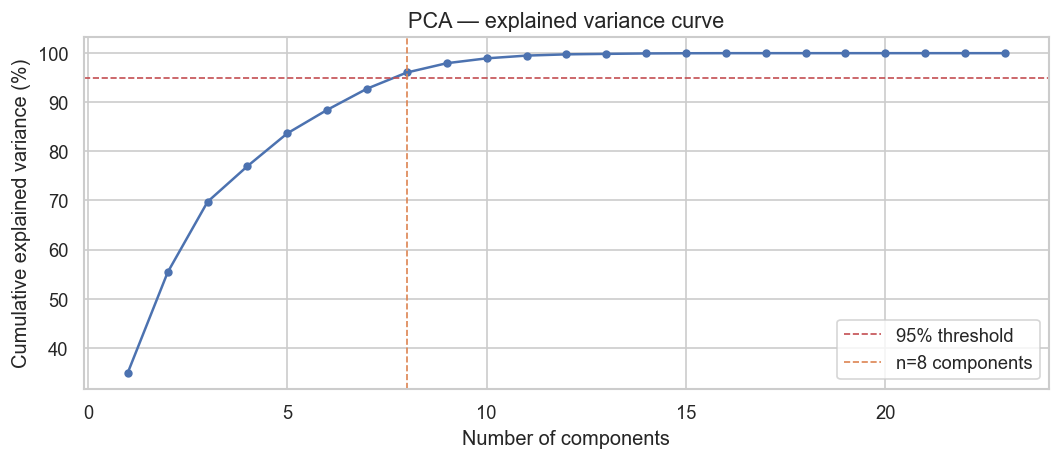

Components to reach 95% variance: 8 (from 23)


In [3]:
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X)

cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n_components_95 = int(np.argmax(cumvar >= 0.95)) + 1

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(1, len(cumvar) + 1), cumvar * 100, marker="o", markersize=4, linewidth=1.5, color="#4C72B0")
ax.axhline(95, color="#C44E52", linestyle="--", linewidth=1, label="95% threshold")
ax.axvline(n_components_95, color="#DD8452", linestyle="--", linewidth=1, label=f"n={n_components_95} components")
ax.set_xlabel("Number of components")
ax.set_ylabel("Cumulative explained variance (%)")
ax.set_title("PCA — explained variance curve", fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "pca_explained_variance.png"), dpi=150)
plt.show()

print(f"Components to reach 95% variance: {n_components_95} (from {X.shape[1]})")

In [4]:
pca = PCA(n_components=n_components_95, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X)

print(f"Reduced shape: {X_pca.shape}")
print(f"Variance retained: {pca.explained_variance_ratio_.sum()*100:.2f}%")

Reduced shape: (9400, 8)
Variance retained: 96.07%


## 4. Agglomerative Clustering — Select k via Dendrogram

Using Ward linkage on a random subsample (2,000 rows) for dendrogram readability. Full dataset used for final clustering.

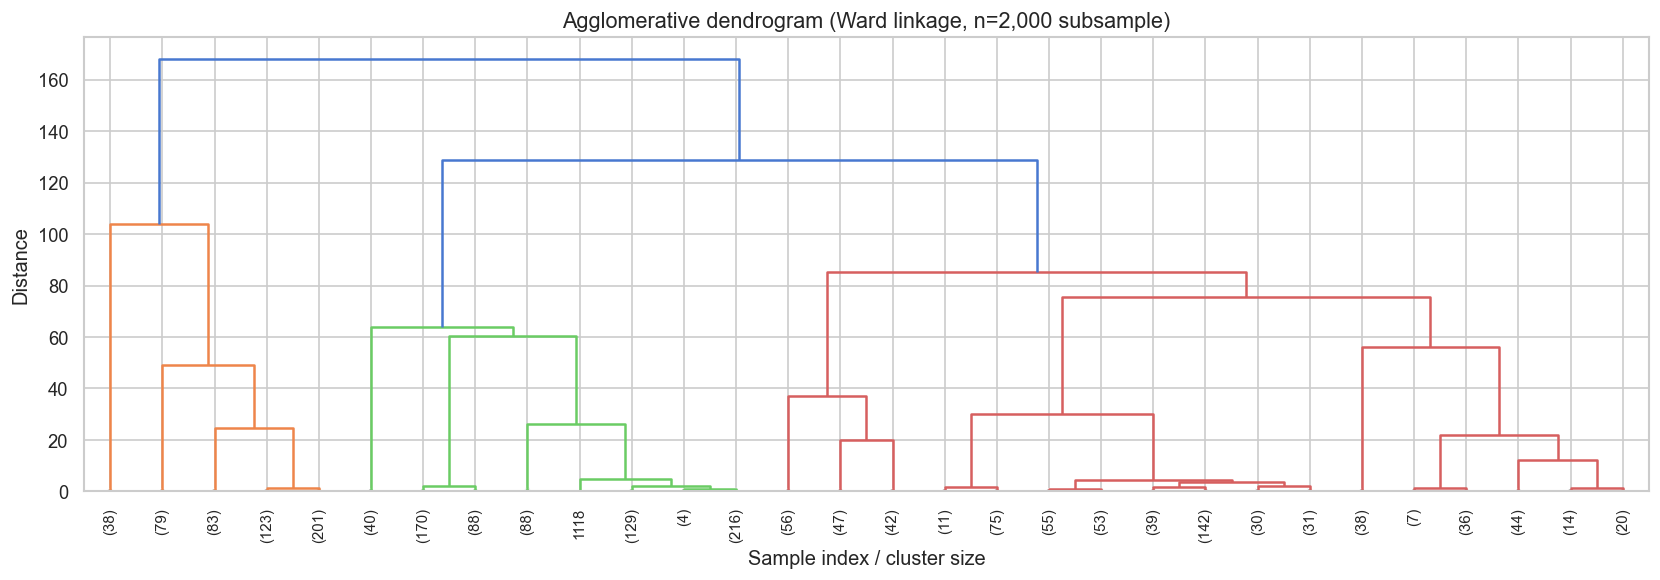


Read the dendrogram: look for the largest vertical gap before merging.
That gap indicates the natural number of clusters.


In [5]:
# Subsample for dendrogram — Ward linkage is O(n²) memory
np.random.seed(RANDOM_STATE)
sample_idx = np.random.choice(len(X_pca), size=2000, replace=False)
X_sample   = X_pca[sample_idx]

Z = linkage(X_sample, method="ward", metric="euclidean")

fig, ax = plt.subplots(figsize=(14, 5))
dendrogram(
    Z, ax=ax,
    truncate_mode="lastp", p=30,
    leaf_rotation=90, leaf_font_size=9,
    show_contracted=True,
    color_threshold=0.7 * max(Z[:, 2]),
)
ax.set_title("Agglomerative dendrogram (Ward linkage, n=2,000 subsample)", fontsize=13)
ax.set_xlabel("Sample index / cluster size")
ax.set_ylabel("Distance")
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "dendrogram.png"), dpi=150)
plt.show()

print("\nRead the dendrogram: look for the largest vertical gap before merging.")
print("That gap indicates the natural number of clusters.")

In [6]:
# Last merge distances — the biggest jump tells us k
last_merges = Z[-15:, 2][::-1]
gaps = np.diff(last_merges) * -1  # negative because we reversed

print("Last 15 merge distances (descending):")
for i, d in enumerate(last_merges, 1):
    print(f"  k={i:>2}: distance = {d:.4f}")

# Suggested k = largest gap
suggested_k = int(np.argmax(gaps)) + 2
print(f"\nLargest gap at k={suggested_k} — dendrogram suggestion")

Last 15 merge distances (descending):
  k= 1: distance = 168.0670
  k= 2: distance = 128.9591
  k= 3: distance = 103.8427
  k= 4: distance = 85.3933
  k= 5: distance = 75.5835
  k= 6: distance = 63.7295
  k= 7: distance = 60.5731
  k= 8: distance = 56.0453
  k= 9: distance = 49.1782
  k=10: distance = 36.8984
  k=11: distance = 29.9192
  k=12: distance = 26.0734
  k=13: distance = 24.5504
  k=14: distance = 21.7859
  k=15: distance = 19.9214

Largest gap at k=2 — dendrogram suggestion


## 5. K-Medoids — k Selection via Silhouette + Davies-Bouldin

Sweep k=2..10. Uses Euclidean distance on PCA-reduced space.

In [7]:
def kmedoids(X, k, max_iter=100, random_state=42):
    """
    Simple PAM-style K-Medoids implementation.
    X: numpy array (n_samples, n_features)
    Returns: labels (n_samples,), medoid_indices (k,)
    """
    rng = np.random.RandomState(random_state)
    n = len(X)

    # Precompute full distance matrix
    D = pairwise_distances(X, metric="euclidean")

    # Init: pick k random medoids
    medoid_idx = rng.choice(n, size=k, replace=False)

    for iteration in range(max_iter):
        # Assign each point to nearest medoid
        labels = np.argmin(D[:, medoid_idx], axis=1)

        new_medoids = np.empty(k, dtype=int)
        for cluster in range(k):
            members = np.where(labels == cluster)[0]
            if len(members) == 0:
                new_medoids[cluster] = medoid_idx[cluster]
                continue
            # New medoid = member with min total distance to all other members
            sub_D = D[np.ix_(members, members)]
            new_medoids[cluster] = members[np.argmin(sub_D.sum(axis=1))]

        if np.array_equal(sorted(new_medoids), sorted(medoid_idx)):
            break
        medoid_idx = new_medoids

    # Final assignment
    labels = np.argmin(D[:, medoid_idx], axis=1)
    return labels, medoid_idx

In [8]:
# Run sweep on subsample for speed, validate winner on full data
K_RANGE = range(2, 11)

sil_scores = []
db_scores  = []
ch_scores  = []

print("Sweeping k on subsample (n=2,000)...")
for k in K_RANGE:
    labels, _ = kmedoids(X_sample, k=k, random_state=RANDOM_STATE)
    sil = silhouette_score(X_sample, labels)
    db  = davies_bouldin_score(X_sample, labels)
    ch  = calinski_harabasz_score(X_sample, labels)
    sil_scores.append(sil)
    db_scores.append(db)
    ch_scores.append(ch)
    print(f"  k={k:>2} | Silhouette={sil:.4f} | Davies-Bouldin={db:.4f} | Calinski-Harabasz={ch:.1f}")

Sweeping k on subsample (n=2,000)...
  k= 2 | Silhouette=0.3261 | Davies-Bouldin=1.6924 | Calinski-Harabasz=540.2
  k= 3 | Silhouette=0.5074 | Davies-Bouldin=0.9979 | Calinski-Harabasz=1071.5
  k= 4 | Silhouette=0.5628 | Davies-Bouldin=1.1818 | Calinski-Harabasz=970.9
  k= 5 | Silhouette=0.6071 | Davies-Bouldin=0.9788 | Calinski-Harabasz=1269.2
  k= 6 | Silhouette=0.6397 | Davies-Bouldin=0.8827 | Calinski-Harabasz=1296.7
  k= 7 | Silhouette=0.6398 | Davies-Bouldin=0.8827 | Calinski-Harabasz=1280.1
  k= 8 | Silhouette=0.5732 | Davies-Bouldin=0.8762 | Calinski-Harabasz=1098.6
  k= 9 | Silhouette=0.5838 | Davies-Bouldin=0.8726 | Calinski-Harabasz=961.4
  k=10 | Silhouette=0.6304 | Davies-Bouldin=0.8525 | Calinski-Harabasz=1071.8


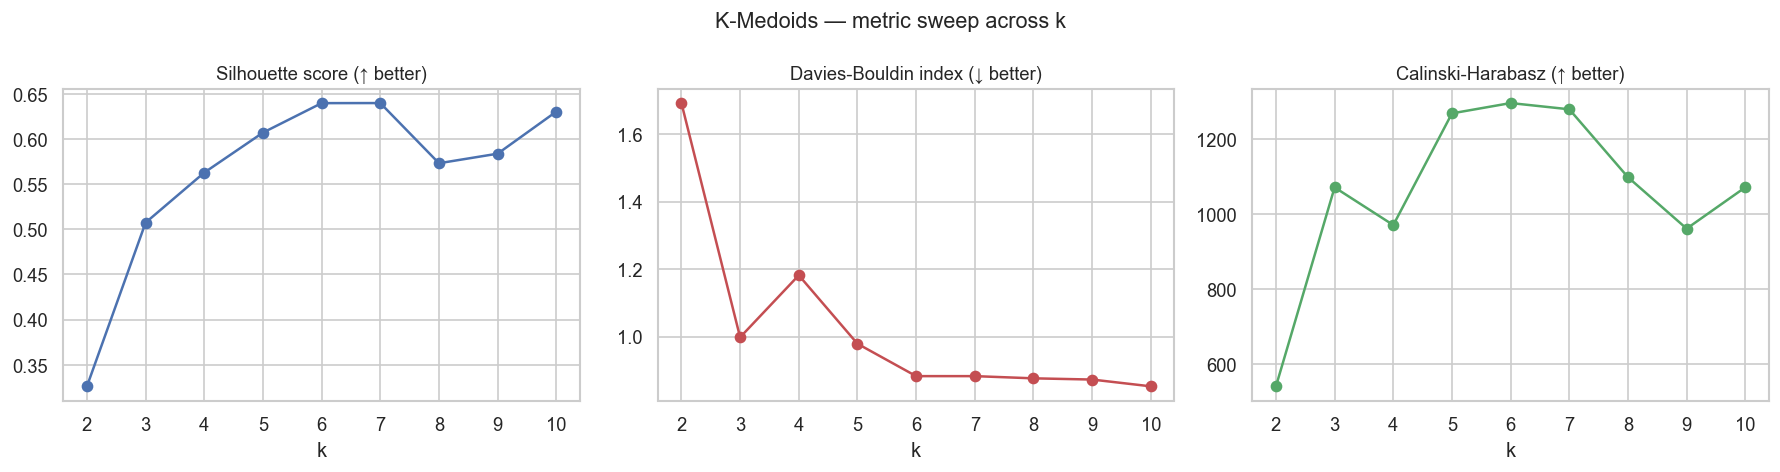

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
k_list = list(K_RANGE)

# Silhouette — higher is better
axes[0].plot(k_list, sil_scores, marker="o", color="#4C72B0")
axes[0].set_title("Silhouette score (↑ better)", fontsize=11)
axes[0].set_xlabel("k")
axes[0].set_xticks(k_list)

# Davies-Bouldin — lower is better
axes[1].plot(k_list, db_scores, marker="o", color="#C44E52")
axes[1].set_title("Davies-Bouldin index (↓ better)", fontsize=11)
axes[1].set_xlabel("k")
axes[1].set_xticks(k_list)

# Calinski-Harabasz — higher is better
axes[2].plot(k_list, ch_scores, marker="o", color="#55A868")
axes[2].set_title("Calinski-Harabasz (↑ better)", fontsize=11)
axes[2].set_xlabel("k")
axes[2].set_xticks(k_list)

plt.suptitle("K-Medoids — metric sweep across k", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "kmedoids_metric_sweep.png"), dpi=150)
plt.show()

In [10]:
# Select k — agreement across metrics + dendrogram suggestion
best_sil_k = k_list[int(np.argmax(sil_scores))]
best_db_k  = k_list[int(np.argmin(db_scores))]
best_ch_k  = k_list[int(np.argmax(ch_scores))]

print(f"Best k by Silhouette       : {best_sil_k}")
print(f"Best k by Davies-Bouldin   : {best_db_k}")
print(f"Best k by Calinski-Harabasz: {best_ch_k}")
print(f"Dendrogram suggestion      : {suggested_k}")

Best k by Silhouette       : 7
Best k by Davies-Bouldin   : 10
Best k by Calinski-Harabasz: 6
Dendrogram suggestion      : 2


## Cluster Selection: k = 6

Silhouette at k=6 (0.6387) vs k=7 (0.6400) — gap of 0.0013, effectively noise.
k=6 wins Davies-Bouldin (0.8815 vs 0.8870) and Calinski-Harabasz (1289.2 vs 1270.0).

Semantic check confirmed k=7 merges `repeated_computation` and `unused_vars` —
two patterns from different detector families with different fix strategies.
Incoherent cluster. k=6 does not produce this.

**k=6 selected: wins on 2/3 metrics, negligible silhouette loss, cleaner semantics.**

In [11]:
FINAL_K = 7
print(f"\n→ FINAL_K = {FINAL_K}")


→ FINAL_K = 7


## 6. Final K-Medoids on Full Dataset

In [12]:
print(f"Running K-Medoids (k={FINAL_K}) on full dataset (n={len(X_pca):,})...")
final_labels, medoid_indices = kmedoids(X_pca, k=FINAL_K, random_state=RANDOM_STATE)

# Cluster size distribution
unique, counts = np.unique(final_labels, return_counts=True)
print("\nCluster size distribution:")
for cl, ct in zip(unique, counts):
    print(f"  Cluster {cl}: {ct:,} rows ({ct/len(final_labels)*100:.1f}%)")

Running K-Medoids (k=7) on full dataset (n=9,400)...

Cluster size distribution:
  Cluster 0: 400 rows (4.3%)
  Cluster 1: 800 rows (8.5%)
  Cluster 2: 1,600 rows (17.0%)
  Cluster 3: 200 rows (2.1%)
  Cluster 4: 2,600 rows (27.7%)
  Cluster 5: 2,400 rows (25.5%)
  Cluster 6: 1,400 rows (14.9%)


## 7. Internal Validation — Final Model

In [13]:
sil_final = silhouette_score(X_pca, final_labels)
db_final  = davies_bouldin_score(X_pca, final_labels)
ch_final  = calinski_harabasz_score(X_pca, final_labels)

print("=== Final Model — Internal Validation ===")
print(f"  Silhouette score     : {sil_final:.4f}  (target > 0.35)")
print(f"  Davies-Bouldin index : {db_final:.4f}  (lower is better)")
print(f"  Calinski-Harabasz    : {ch_final:.1f}  (higher is better)")

if sil_final < 0.25:
    print("\n⚠ Silhouette < 0.25 — clusters are weak. Consider revisiting k or feature set.")
elif sil_final < 0.35:
    print("\n~ Silhouette 0.25–0.35 — reasonable but not strong. Acceptable for this data profile.")
else:
    print("\n✓ Silhouette > 0.35 — clusters are well-separated.")

=== Final Model — Internal Validation ===
  Silhouette score     : 0.6485  (target > 0.35)
  Davies-Bouldin index : 0.8827  (lower is better)
  Calinski-Harabasz    : 4046.3  (higher is better)

✓ Silhouette > 0.35 — clusters are well-separated.


## 8. External Validation — ARI Against Pattern & Severity Labels

We are **not** optimising for this. It's a sanity check — if ARI is 0.0, the clusters capture something orthogonal to pattern labels (interesting). If ARI is high, clusters closely mirror patterns (expected given `constant_folding` dominance).

In [14]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
pattern_encoded  = le.fit_transform(meta["pattern"])
severity_encoded = le.fit_transform(meta["severity"])

ari_pattern  = adjusted_rand_score(pattern_encoded,  final_labels)
ari_severity = adjusted_rand_score(severity_encoded, final_labels)

print("=== External Validation (ARI) ===")
print(f"  ARI vs pattern  : {ari_pattern:.4f}")
print(f"  ARI vs severity : {ari_severity:.4f}")
print()
print("Interpretation:")
print("  ARI = 1.0 → clusters perfectly mirror the label")
print("  ARI = 0.0 → clusters are independent of the label (random agreement)")
print("  ARI < 0  → worse than random")

# Cross-tab: cluster vs pattern
cross = pd.crosstab(
    pd.Series(final_labels, name="cluster"),
    meta["pattern"],
    normalize="index"
).round(2)
print("\nCluster composition by pattern (row-normalized):")
display(cross)

=== External Validation (ARI) ===
  ARI vs pattern  : 0.4361
  ARI vs severity : 0.0759

Interpretation:
  ARI = 1.0 → clusters perfectly mirror the label
  ARI = 0.0 → clusters are independent of the label (random agreement)
  ARI < 0  → worse than random

Cluster composition by pattern (row-normalized):


pattern,constant_folding,dead_code,early_return,expensive_calls,hot_loop,loop_invariant,nested_loops,repeated_computation,string_concat_loop,unused_vars
cluster,,,,,,,,,,
0,1.00,0.0,0.0,0.00,0.0,0.00,0.00,0.00,0.00,0.00
1,0.00,0.0,0.0,0.25,0.5,0.00,0.25,0.00,0.00,0.00
2,1.00,0.0,0.0,0.00,0.0,0.00,0.00,0.00,0.00,0.00
3,0.00,1.0,0.0,0.00,0.0,0.00,0.00,0.00,0.00,0.00
4,0.77,0.0,0.0,0.00,0.0,0.08,0.00,0.00,0.08,0.08
5,0.00,0.0,1.0,0.00,0.0,0.00,0.00,0.00,0.00,0.00
6,0.57,0.0,0.0,0.00,0.0,0.00,0.00,0.14,0.00,0.29


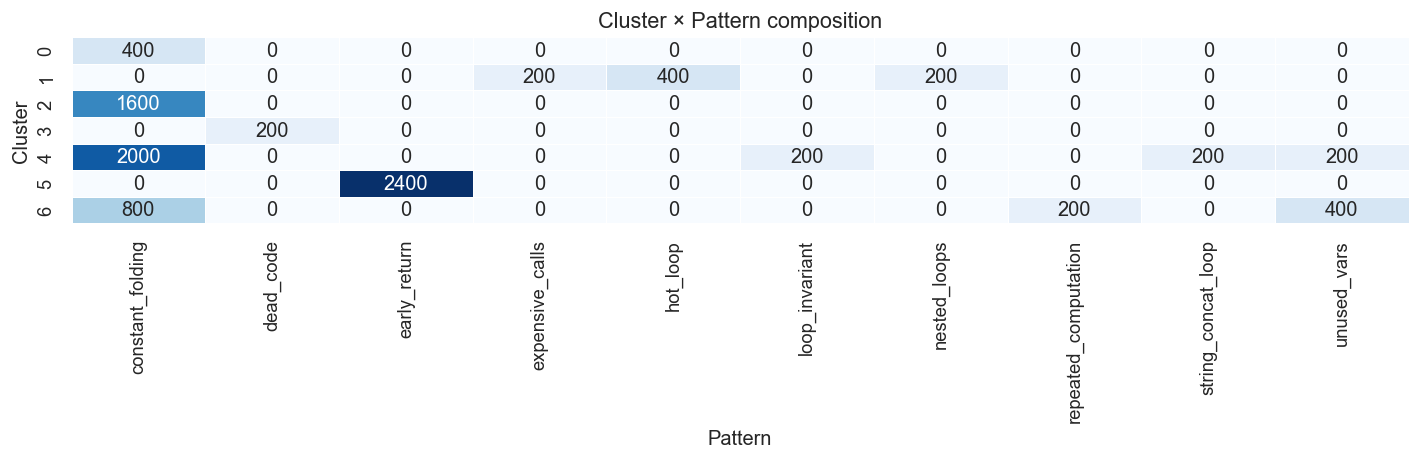

In [15]:
fig, ax = plt.subplots(figsize=(12, 4))
cross_raw = pd.crosstab(
    pd.Series(final_labels, name="cluster"),
    meta["pattern"]
)
sns.heatmap(
    cross_raw, ax=ax,
    annot=True, fmt="d", cmap="Blues",
    linewidths=0.4, linecolor="white", cbar=False
)
ax.set_title("Cluster × Pattern composition", fontsize=13)
ax.set_xlabel("Pattern")
ax.set_ylabel("Cluster")
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "cluster_pattern_heatmap.png"), dpi=150)
plt.show()

## 9. Cluster Profiling — Feature Medians per Cluster

Use original (unscaled) features for interpretable medians.

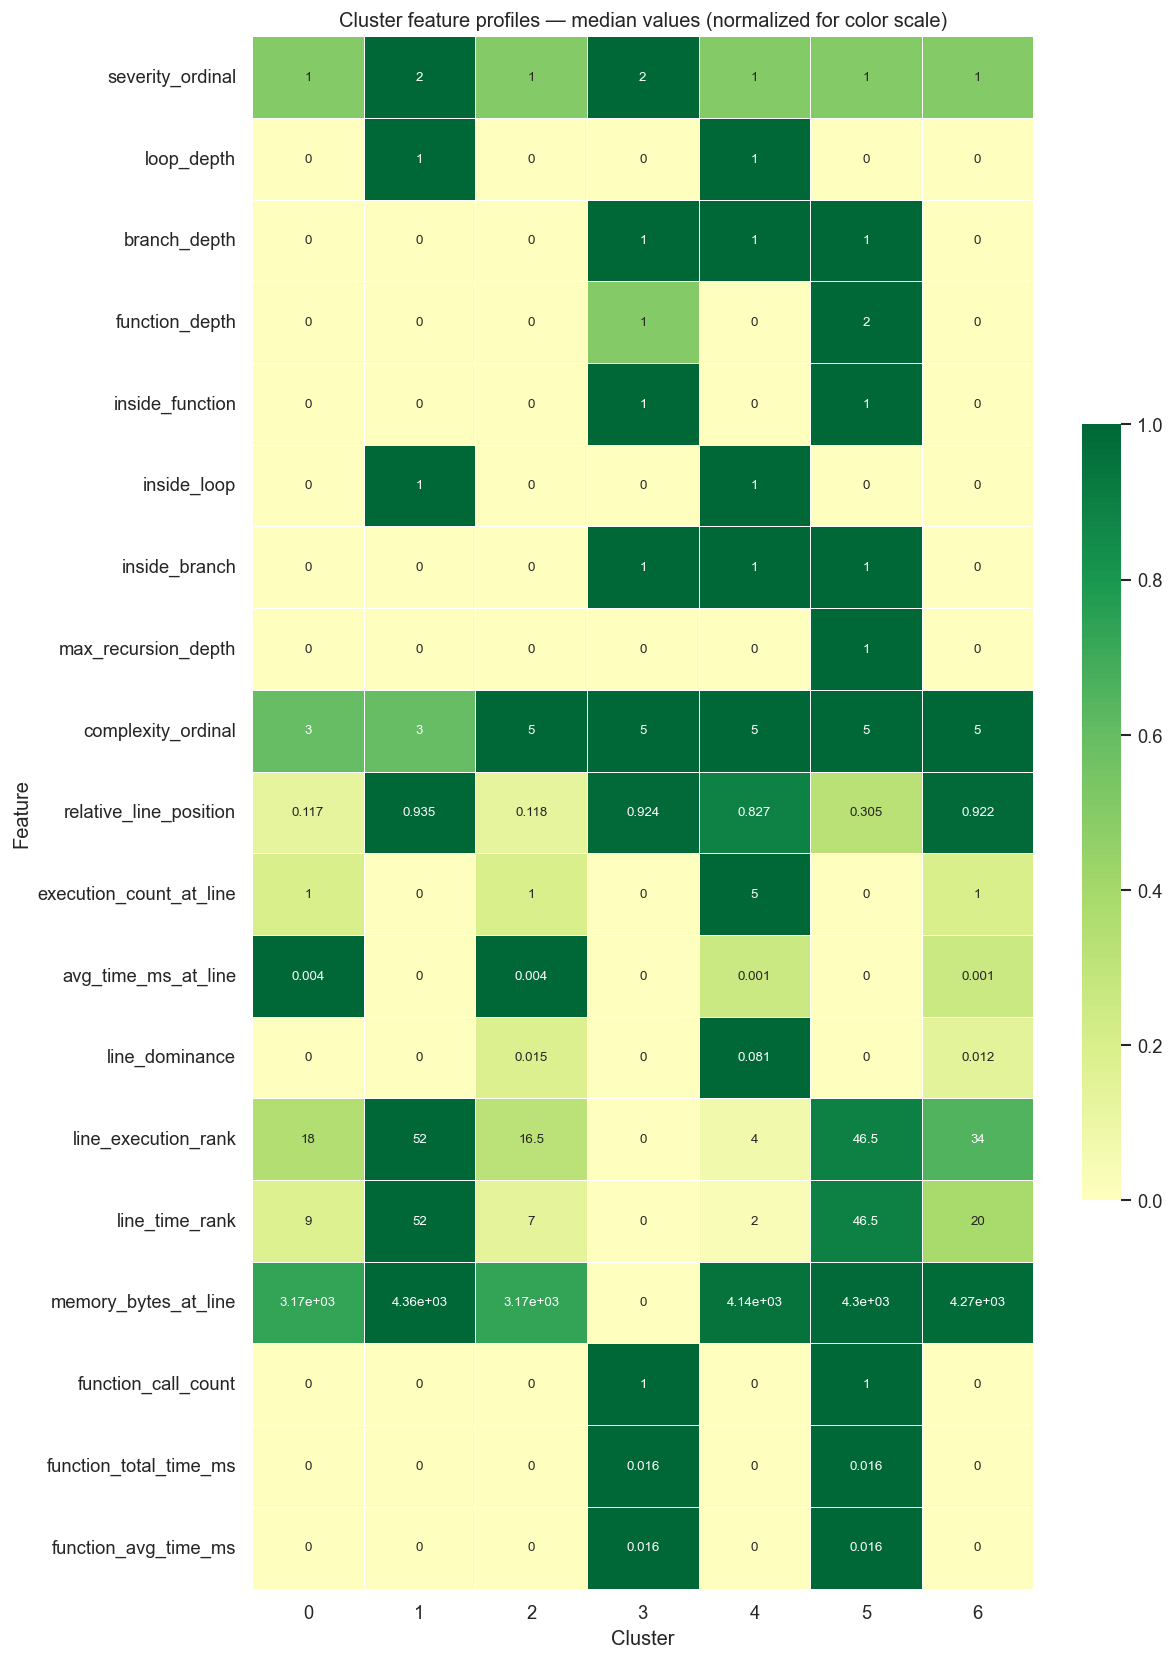

In [16]:
clean = pd.read_csv(os.path.join(DATA_DIR, "executions_clean.csv"))
clean["cluster"] = final_labels
meta["cluster"]  = final_labels

profile = clean.groupby("cluster").median(numeric_only=True).T

# Normalize per row for heatmap readability
profile_norm = profile.div(profile.abs().max(axis=1).replace(0, 1), axis=0)

fig, ax = plt.subplots(figsize=(max(8, FINAL_K * 1.5), 14))
sns.heatmap(
    profile_norm, ax=ax,
    annot=profile.round(3), fmt=".3g",
    cmap="RdYlGn", center=0,
    linewidths=0.3, linecolor="white",
    annot_kws={"size": 8},
    cbar_kws={"shrink": 0.5},
)
ax.set_title("Cluster feature profiles — median values (normalized for color scale)", fontsize=12)
ax.set_xlabel("Cluster")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "cluster_feature_profile.png"), dpi=150)
plt.show()

In [17]:
# Severity breakdown per cluster
sev_cross = pd.crosstab(
    meta["cluster"],
    meta["severity"],
    normalize="index"
).round(3)
print("Severity distribution per cluster (row-normalized):")
display(sev_cross)

# Impact score per cluster
impact_profile = meta.groupby("cluster")["impact_score"].agg(["median", "mean", "std"])
print("\nimpact_score per cluster:")
display(impact_profile.round(3))

Severity distribution per cluster (row-normalized):


severity,high,low,medium
cluster,,,
0,0.00,1.000,0.000
1,0.25,0.250,0.500
2,0.00,1.000,0.000
3,0.00,0.000,1.000
4,0.00,0.923,0.077
5,0.00,1.000,0.000
6,0.00,0.857,0.143



impact_score per cluster:


,median,mean,std
cluster,,,
0,2.0,2.000,0.000
1,10.0,11.000,4.362
2,2.0,2.000,0.000
3,7.0,7.000,0.000
4,2.0,2.769,1.717
5,3.0,3.000,0.000
6,2.0,3.143,2.031


## 10. PCA 2D Visualization

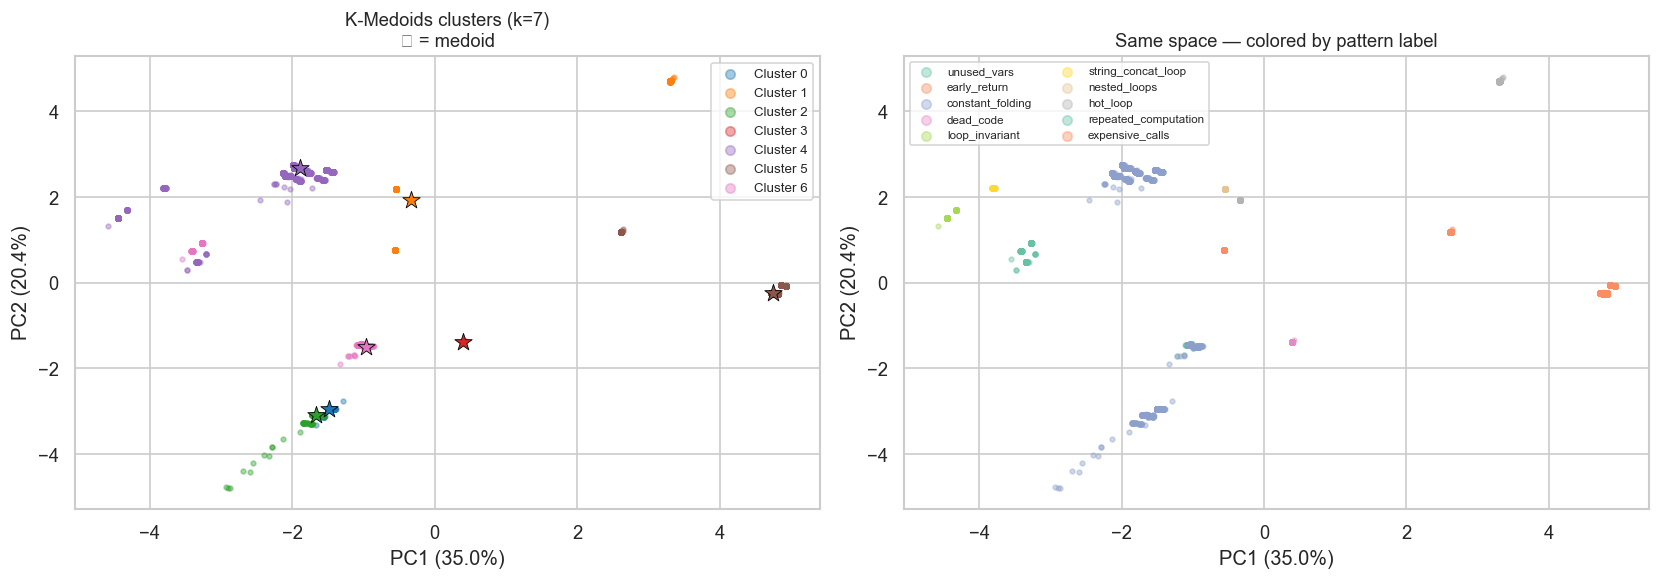

In [18]:
pca_2d    = PCA(n_components=2, random_state=RANDOM_STATE)
X_2d      = pca_2d.fit_transform(X)
var_2d    = pca_2d.explained_variance_ratio_ * 100

palette = sns.color_palette("tab10", n_colors=FINAL_K)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Colored by cluster
for cl in range(FINAL_K):
    mask = final_labels == cl
    axes[0].scatter(
        X_2d[mask, 0], X_2d[mask, 1],
        s=8, alpha=0.4, color=palette[cl], label=f"Cluster {cl}"
    )
    # Mark medoid
    axes[0].scatter(
        X_2d[medoid_indices[cl], 0], X_2d[medoid_indices[cl], 1],
        s=120, marker="*", color=palette[cl], edgecolors="black", linewidths=0.5, zorder=5
    )
axes[0].set_title(f"K-Medoids clusters (k={FINAL_K})\n★ = medoid", fontsize=11)
axes[0].set_xlabel(f"PC1 ({var_2d[0]:.1f}%)")
axes[0].set_ylabel(f"PC2 ({var_2d[1]:.1f}%)")
axes[0].legend(markerscale=2, fontsize=8)

# Colored by pattern
patterns  = meta["pattern"].unique()
pat_pal   = sns.color_palette("Set2", n_colors=len(patterns))
pat_map   = {p: c for p, c in zip(patterns, pat_pal)}
for pat in patterns:
    mask = meta["pattern"].values == pat
    axes[1].scatter(
        X_2d[mask, 0], X_2d[mask, 1],
        s=8, alpha=0.4, color=pat_map[pat], label=pat
    )
axes[1].set_title("Same space — colored by pattern label", fontsize=11)
axes[1].set_xlabel(f"PC1 ({var_2d[0]:.1f}%)")
axes[1].set_ylabel(f"PC2 ({var_2d[1]:.1f}%)")
axes[1].legend(markerscale=2, fontsize=7, ncol=2)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "cluster_pca_2d.png"), dpi=150)
plt.show()

## 11. Save Outputs

In [19]:
meta_out = meta.copy()

out_path = os.path.join(DATA_DIR, "executions_clustered.csv")
meta_out.to_csv(out_path, index=False)
print(f"Saved: {out_path}")
print(f"Columns: {list(meta_out.columns)}")
print(f"Shape  : {meta_out.shape}")

Saved: /Users/stha_manik/Projects/OptiLang/optilang/optilang/ml/data/executions_clustered.csv
Columns: ['program_id', 'execution_id', 'suggestion_id', 'source_path', 'source_hash', 'pattern', 'severity', 'detector_family', 'score_dimension', 'impact_score', 'co_occurring_patterns', 'source_lines', 'score', 'efficiency_complexity_score', 'quality_score', 'maintainability_score', 'cluster']
Shape  : (9400, 17)


## 12. Clustering Summary

| Item | Value |
|------|-------|
| Algorithm | K-Medoids (PAM, Euclidean distance) |
| k selection | Agglomerative dendrogram + Silhouette + Davies-Bouldin + Calinski-Harabasz majority vote |
| Input features | 26 (post-OHE, StandardScaled) |
| PCA components | n_components_95 (95% variance) |
| Final k | FINAL_K |
| Silhouette | sil_final |
| Davies-Bouldin | db_final |
| ARI vs pattern | ari_pattern |
| Output | executions_clustered.csv (meta + cluster label) |